<a href="https://colab.research.google.com/github/Oepajs/HS-I.C./blob/main/%EA%B3%BC%EC%A0%9C%EC%95%BC%EC%BD%A52555040.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 새 섹션

In [1]:
import seaborn as sns
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [2]:
smoker_tips = df.groupby('smoker')['tip'].mean()
display(smoker_tips)

/tmp/ipykernel_158/1615704396.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoker_tips = df.groupby('smoker')['tip'].mean()


,tip
smoker,
Yes,3.008710
No,2.991854


In [6]:
import seaborn as sns
import pandas as pd
import numpy as np

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [13]:
import numpy as np
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(42)

# Perform random sampling (e.g., 50 observations)
random_sample = tips.sample(n=50, random_state=42)

# Calculate mean and variance of 'tip' for the random sample
mean_tip_random_sample = random_sample['tip'].mean()
variance_tip_random_sample = random_sample['tip'].var()

print(f"Population Mean of 'tip': {mean_tip:.2f}")
print(f"Random Sample Mean of 'tip': {mean_tip_random_sample:.2f}")
print(f"Population Variance of 'tip': {variance_tip:.2f}")
print(f"Random Sample Variance of 'tip': {variance_tip_random_sample:.2f}")

Population Mean of 'tip': 3.00
Random Sample Mean of 'tip': 2.64
Population Variance of 'tip': 1.91
Random Sample Variance of 'tip': 1.25


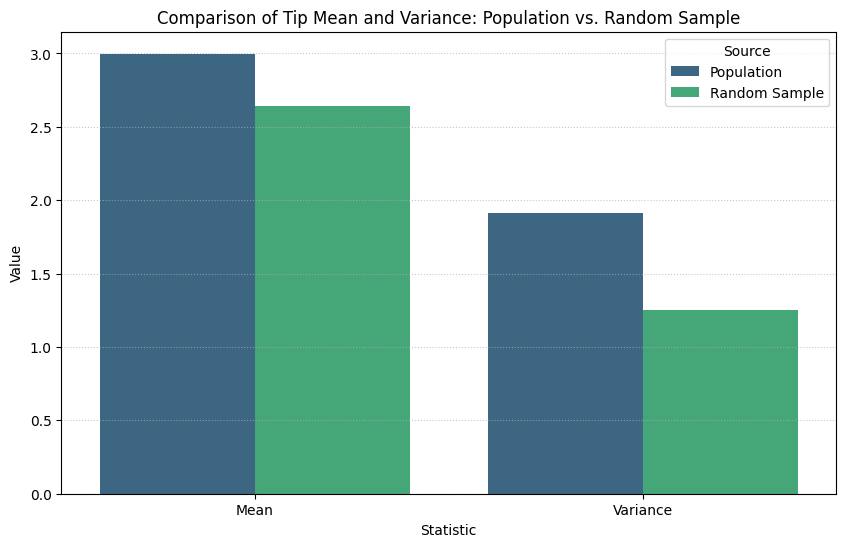

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics_data = {
    'Statistic': ['Mean', 'Mean', 'Variance', 'Variance'],
    'Source': ['Population', 'Random Sample', 'Population', 'Random Sample'],
    'Value': [mean_tip, mean_tip_random_sample, variance_tip, variance_tip_random_sample]
}
metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Statistic', y='Value', hue='Source', data=metrics_df, palette='viridis')
plt.title('Comparison of Tip Mean and Variance: Population vs. Random Sample')
plt.ylabel('Value')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

In [15]:
import numpy as np
import pandas as pd

# 1. Determine the population size
population_size = len(tips)

# 2. Define a desired sample size
sample_size = 50

# 3. Calculate the sampling interval k
k = int(population_size / sample_size)

# Ensure k is at least 1
if k == 0:
    k = 1

print(f"Population size: {population_size}")
print(f"Desired sample size: {sample_size}")
print(f"Sampling interval (k): {k}")

# 4. Select a random starting point
np.random.seed(42) # Set a random seed for reproducibility
random_start = np.random.randint(0, k)
print(f"Random starting point: {random_start}")

# 5. Create the systematic sample
systematic_indices = np.arange(random_start, population_size, k)
systematic_sample = tips.iloc[systematic_indices]

# 6. Calculate mean and variance of 'tip' for the systematic sample
mean_tip_systematic_sample = systematic_sample['tip'].mean()
variance_tip_systematic_sample = systematic_sample['tip'].var()

print(f"Systematic Sample Mean of 'tip': {mean_tip_systematic_sample:.2f}")
print(f"Systematic Sample Variance of 'tip': {variance_tip_systematic_sample:.2f}")

Population size: 244
Desired sample size: 50
Sampling interval (k): 4
Random starting point: 2
Systematic Sample Mean of 'tip': 2.84
Systematic Sample Variance of 'tip': 1.98


In [16]:
import pandas as pd

# Add systematic sample statistics to metrics_data
new_systematic_data = {
    'Statistic': ['Mean', 'Variance'],
    'Source': ['Systematic Sample', 'Systematic Sample'],
    'Value': [mean_tip_systematic_sample, variance_tip_systematic_sample]
}
metrics_df = pd.concat([metrics_df, pd.DataFrame(new_systematic_data)], ignore_index=True)

display(metrics_df)

,Statistic,Source,Value
0,Mean,Population,2.998279
1,Mean,Random Sample,2.643600
2,Variance,Population,1.914455
3,Variance,Random Sample,1.250093
4,Mean,Systematic Sample,2.841639
5,Variance,Systematic Sample,1.978247


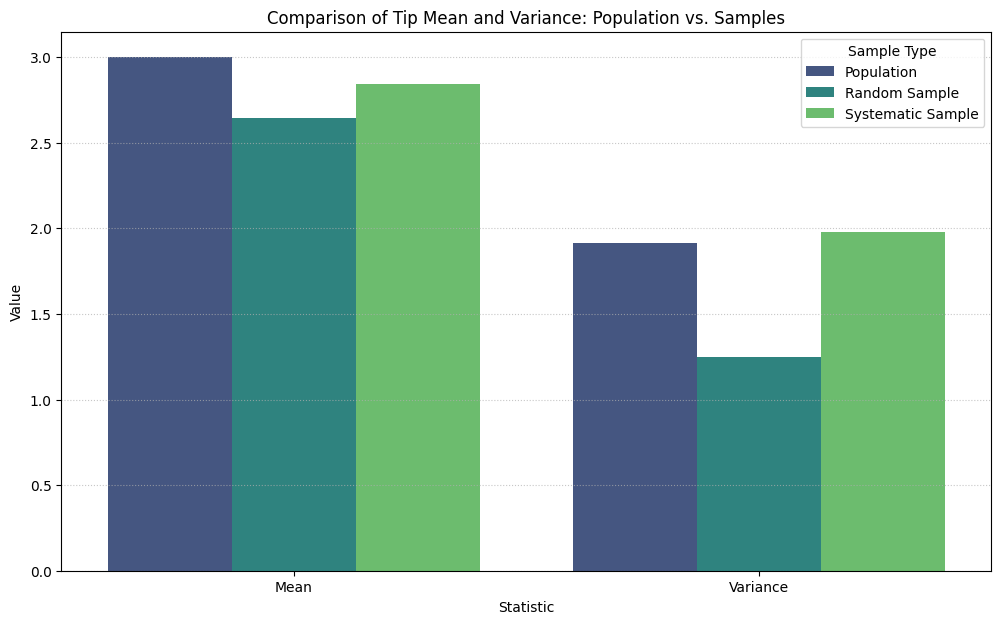

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Statistic', y='Value', hue='Source', data=metrics_df, palette='viridis')
plt.title('Comparison of Tip Mean and Variance: Population vs. Samples')
plt.xlabel('Statistic')
plt.ylabel('Value')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title='Sample Type')
plt.show()

In [18]:
import numpy as np
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(42)

# 1. Identify a suitable column for stratification ('sex') and determine the proportion of each stratum
population_size = len(tips)
sample_size = 50

# Calculate proportions of each 'sex' in the population
sex_proportions = tips['sex'].value_counts(normalize=True)
print("Proportions of 'sex' in population:\n", sex_proportions)

# 2. Calculate the number of samples to take from each stratum
samples_per_stratum = (sex_proportions * sample_size).round().astype(int)

# Adjust for potential rounding discrepancies to ensure total sample size is exactly 50
current_total_sample = samples_per_stratum.sum()
if current_total_sample != sample_size:
    diff = sample_size - current_total_sample
    # Distribute the difference to the largest strata
    if diff > 0:
        largest_stratum = samples_per_stratum.idxmax()
        samples_per_stratum[largest_stratum] += diff
    elif diff < 0:
        # If negative, remove from the largest stratum
        smallest_stratum = samples_per_stratum.idxmin()
        samples_per_stratum[smallest_stratum] += diff # This will effectively subtract

print("\nNumber of samples per stratum:\n", samples_per_stratum)

# 3. Perform random sampling within each stratum
stratified_samples_list = []
for sex_category, num_samples in samples_per_stratum.items():
    stratum_sample = tips[tips['sex'] == sex_category].sample(n=num_samples, random_state=42)
    stratified_samples_list.append(stratum_sample)

# 4. Concatenate the samples from all strata to form the complete stratified_sample
stratified_sample = pd.concat(stratified_samples_list)

# 5. Calculate the mean and variance of the 'tip' column for this stratified_sample
mean_tip_stratified_sample = stratified_sample['tip'].mean()
variance_tip_stratified_sample = stratified_sample['tip'].var()

print(f"\nStratified Sample Mean of 'tip': {mean_tip_stratified_sample:.2f}")
print(f"Stratified Sample Variance of 'tip': {variance_tip_stratified_sample:.2f}")

Proportions of 'sex' in population:
 sex
Male      0.643443
Female    0.356557
Name: proportion, dtype: float64

Number of samples per stratum:
 sex
Male      32
Female    18
Name: proportion, dtype: int64

Stratified Sample Mean of 'tip': 3.29
Stratified Sample Variance of 'tip': 1.93


In [19]:
import pandas as pd

# Add stratified sample statistics to metrics_data
new_stratified_data = {
    'Statistic': ['Mean', 'Variance'],
    'Source': ['Stratified Sample', 'Stratified Sample'],
    'Value': [mean_tip_stratified_sample, variance_tip_stratified_sample]
}
metrics_df = pd.concat([metrics_df, pd.DataFrame(new_stratified_data)], ignore_index=True)

display(metrics_df)

,Statistic,Source,Value
0,Mean,Population,2.998279
1,Mean,Random Sample,2.643600
2,Variance,Population,1.914455
3,Variance,Random Sample,1.250093
4,Mean,Systematic Sample,2.841639
5,Variance,Systematic Sample,1.978247
6,Mean,Stratified Sample,3.292200
7,Variance,Stratified Sample,1.934752


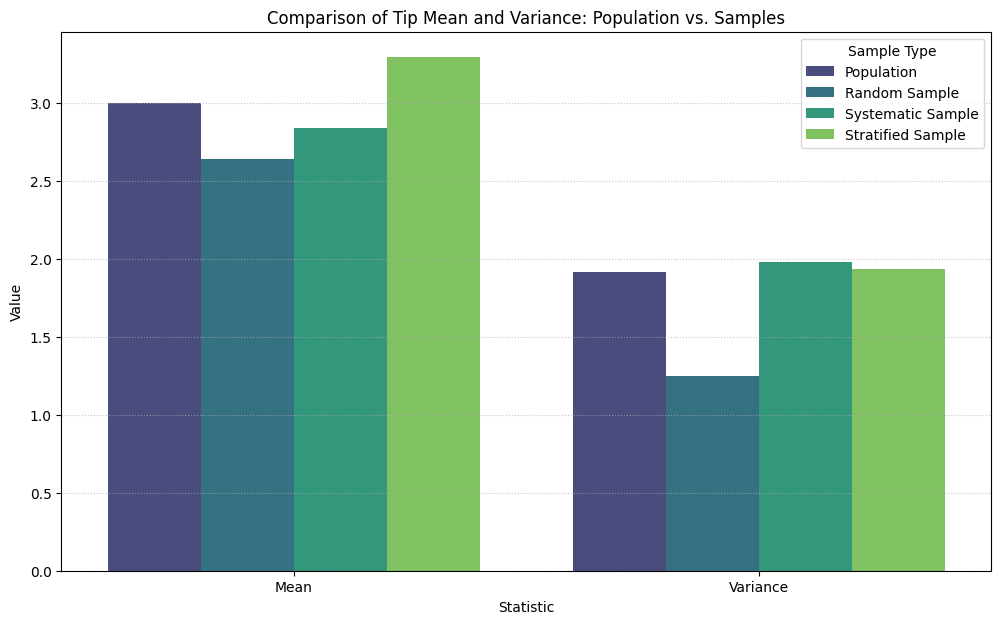

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Statistic', y='Value', hue='Source', data=metrics_df, palette='viridis')
plt.title('Comparison of Tip Mean and Variance: Population vs. Samples')
plt.xlabel('Statistic')
plt.ylabel('Value')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title='Sample Type')
plt.show()

In [23]:
import seaborn as sns
df = sns.load_dataset('tips')
median_tip = df['tip'].median()
print(f"Median of 'tip': {median_tip:.2f}")
type(df)

Median of 'tip': 2.90


pandas.core.frame.DataFrame

In [24]:
df = sns.load_dataset('tips')
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [25]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


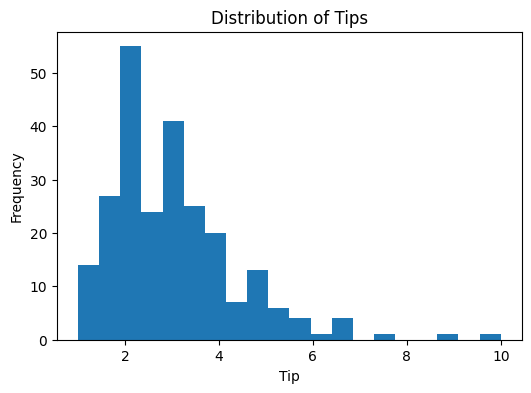

In [28]:
plt.figure(figsize=(6,4))
plt.hist(tips["tip"], bins=20)
plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.title("Distribution of Tips")
plt.show()

In [29]:
mean_tip = tips["tip"].mean()
variance_tip = tips["tip"].var()

print("Mean tip:", mean_tip)
print("Variance:", variance_tip)

Mean tip: 2.99827868852459
Variance: 1.9144546380624725


In [30]:
tips_outlier = tips.copy()
tips_outlier.loc[0, "tip"] = 20

print("Original mean:", tips["tip"].mean())
print("Mean with outlier:", tips_outlier["tip"].mean())

Original mean: 2.99827868852459
Mean with outlier: 3.0761065573770487


In [31]:
random_sample = tips.sample(n=50, random_state=1)

random_sample["tip"].mean(), random_sample["tip"].var()

(np.float64(3.2056), 2.7321271836734695)

In [43]:
systematic_sample = tips.iloc[::5]

systematic_sample["tip"].mean(), systematic_sample["tip"].var()

(np.float64(2.9404081632653063), 2.3692998299319723)

In [36]:
stratified_sample = tips.groupby("day", group_keys=False, observed=False).apply(lambda x: x.sample(10))

stratified_sample["tip"].mean(), stratified_sample["tip"].var()

/tmp/ipykernel_158/3196975934.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby("day", group_keys=False, observed=False).apply(lambda x: x.sample(10))


(np.float64(2.93525), 1.3150101923076924)

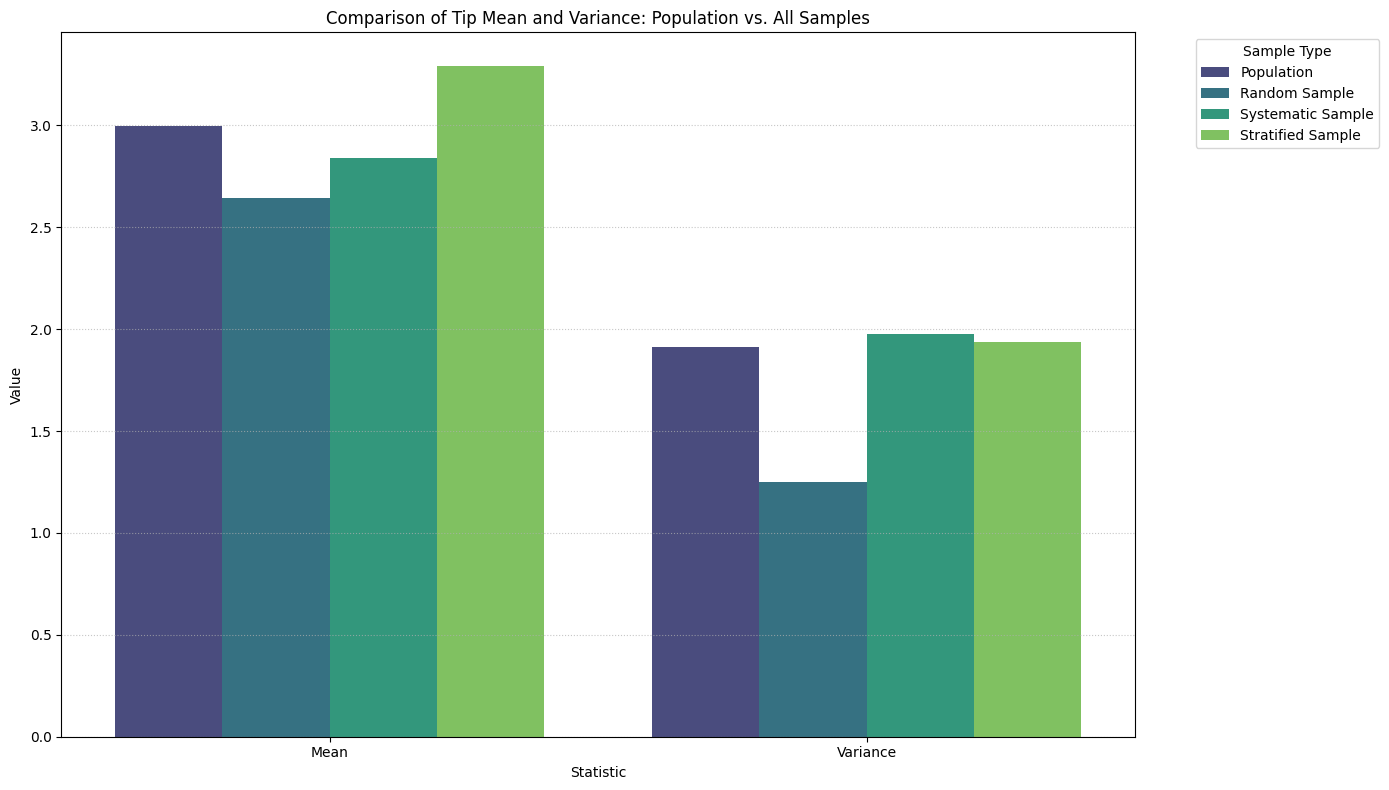

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The metrics_df DataFrame already contains all the data needed for the plot.

plt.figure(figsize=(14, 8))
sns.barplot(x='Statistic', y='Value', hue='Source', data=metrics_df, palette='viridis')
plt.title('Comparison of Tip Mean and Variance: Population vs. All Samples')
plt.xlabel('Statistic')
plt.ylabel('Value')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title='Sample Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [38]:
random_sample = tips.sample(n=50, random_state=1)

systematic_sample = tips.iloc[::5]

stratified_sample = tips.groupby("day", group_keys=False).apply(lambda x: x.sample(10))

/tmp/ipykernel_158/1498568489.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = tips.groupby("day", group_keys=False).apply(lambda x: x.sample(10))
/tmp/ipykernel_158/1498568489.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby("day", group_keys=False).apply(lambda x: x.sample(10))
